**Разархивируем архив**

In [ ]:
!unzip -q tiny-imagenet-200.zip

**Выбор классов**

In [ ]:
selected_classes = [
'n02769748',
"n02099712",
"n07695742",
"n02056570",
"n02281406",
"n01774750",
"n02509815",
"n03983396",
"n07753592",
"n04254777",
]

**1. Поготовка данных**

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os

class TinyImageNetDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None, split="train"):
        self.root_dir = root_dir
        self.classes = classes
        self.transform = transform

        self.images = []
        self.labels = []

        self.samples = []
        self.class_to_idx = {cls:i for i, cls in enumerate(self.classes)}
        self.idx_to_class = {i:cls for i, cls in enumerate(self.classes)}

        for cls in selected_classes:
          cls_folder = f"{root_dir}/train/{cls}/images"
          for img_name in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_name)
            self.samples.append((img_path, self.class_to_idx[cls]))

        if split == "train":
            for label, cls in enumerate(classes):
                img_dir = os.path.join(root_dir, "train", cls, "images")

                if not os.path.exists(img_dir):
                    print("Missing:", img_dir)
                    continue

                for img_name in os.listdir(img_dir):
                    self.images.append(os.path.join(img_dir, img_name))
                    self.labels.append(label)

        elif split == "val":
            ann_path = os.path.join(root_dir, "val", "val_annotations.txt")
            img_dir = os.path.join(root_dir, "val", "images")

            with open(ann_path) as f:
                for line in f:
                    img_name, cls_id, *_ = line.strip().split("\t")
                    if cls_id in classes:
                        self.images.append(os.path.join(img_dir, img_name))
                        self.labels.append(classes.index(cls_id))

        else:
            raise ValueError("split must be 'train' or 'val'")

        print(f"{split} samples loaded: {len(self.images)}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


**2.1. Реализация Basic Block**

Создайте базовый residual блок со следующей структурой:

```
Input
  ↓
Conv2d(kernel_size=3, padding=1, stride=stride)
  ↓
BatchNorm2d
  ↓
ReLU
  ↓
Conv2d(kernel_size=3, padding=1, stride=1)
  ↓
BatchNorm2d
  ↓
  + ← Skip Connection (с возможностью downsample)
  ↓
ReLU
  ↓
Output
```
**Важно:**

Если входные и выходные размерности не совпадают, используйте skip connection с Conv2d(1x1) + BatchNorm2d

Первый residual блок может иметь stride=2 для уменьшения пространственного размера

In [ ]:
import torch
import torch.nn as nn


class BasicBlock(nn.Module):
    expansion = 1  # как в ResNet18/34

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        # --- Main path ---
        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # --- Skip path (по умолчанию identity) ---
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            # Выравниваем размер через 1×1 свёртку
            self.downsample = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x  # сохраняем вход

        # === Main path ===
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # === Skip connection ===
        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        out = self.relu(out)

        return out


**2.2. Реализация ResNet18**

Создайте архитектуру ResNet18 со следующей структурой:

```
Input (3, 64, 64)
  ↓
Conv2d(3→64, kernel_size=7, stride=2, padding=3)  # или 3x3, stride=1 для Tiny ImageNet
  ↓
BatchNorm2d
  ↓
ReLU
  ↓
MaxPool2d(kernel_size=3, stride=2, padding=1)  # опционально для Tiny ImageNet
  ↓
Layer1: 2x Basic Block (64 channels)
  ↓
Layer2: 2x Basic Block (128 channels, stride=2 в первом блоке)
  ↓
Layer3: 2x Basic Block (256 channels, stride=2 в первом блоке)
  ↓
Layer4: 2x Basic Block (512 channels, stride=2 в первом блоке)  # ОПЦИОНАЛЬНО
  ↓
AdaptiveAvgPool2d(output_size=(1, 1))
  ↓
Flatten
  ↓
Linear(512 → 10)  # 10 классов
  ↓
Output
```



In [ ]:
class ResNet18_Lite(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # --- Stem ---
        self.conv1 = nn.Conv2d(
            3, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # --- Stages ---
        self.layer1 = self._make_layer(64, 64, blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, blocks=2, stride=2)

        # Layer4 removed to meet <5M params
        # self.layer4 = self._make_layer(256, 512, blocks=2, stride=2)

        # --- Classification ---
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = []
        layers.append(BasicBlock(in_channels, out_channels, stride))
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        # x = self.layer4(x)  # removed

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

**2.3. Ограничения для базовой модели:**

*   Общее количество параметров: не более 5 миллионов
*   Максимальное количество каналов: до 512

In [ ]:
model = ResNet18_Lite(num_classes=10)
col_parametrs = sum(p.numel() for p in model.parameters())
print(f'Количество параметров\n {col_parametrs} ({col_parametrs/1e6:.2f} М)')

Количество параметров
 2785354 (2.79 М)


**Полный training split**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt


# === TRAIN ONE EPOCH ===
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # accuracy
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    acc = correct / total

    return avg_loss, acc


# === VALIDATION ===
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            # accuracy
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    acc = correct / total

    return avg_loss, acc


**Подготвливаем данные для тренировки**

In [ ]:
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

val_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

In [ ]:
train_dataset = TinyImageNetDataset("tiny-imagenet-200", selected_classes, transform=train_transform, split="train")
val_dataset   = TinyImageNetDataset("tiny-imagenet-200", selected_classes, transform=val_transform, split="val")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

train samples loaded: 5000
val samples loaded: 500


**Основной тренировочный цикл**

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ResNet18_Lite(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

epochs = 20   # можно увеличить до 30

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(1, epochs + 1):
    print(f"\nEPOCH {epoch}/{epochs}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")



EPOCH 1/20


Train Loss: 1.7456 | Train Acc: 0.3880
Val   Loss: 1.6245 | Val   Acc: 0.4480

EPOCH 2/20


Train Loss: 1.3950 | Train Acc: 0.5214
Val   Loss: 1.7318 | Val   Acc: 0.4400

EPOCH 3/20


Train Loss: 1.2035 | Train Acc: 0.5910
Val   Loss: 1.5338 | Val   Acc: 0.4960

EPOCH 4/20


Train Loss: 1.0788 | Train Acc: 0.6348
Val   Loss: 1.4973 | Val   Acc: 0.5020

EPOCH 5/20


...

Train Loss: 0.0998 | Train Acc: 0.9694
Val   Loss: 1.6799 | Val   Acc: 0.6200

EPOCH 17/20


Train Loss: 0.0474 | Train Acc: 0.9884
Val   Loss: 1.8339 | Val   Acc: 0.6180

EPOCH 18/20


Train Loss: 0.0282 | Train Acc: 0.9940
Val   Loss: 1.7160 | Val   Acc: 0.6160

EPOCH 19/20


Train Loss: 0.1170 | Train Acc: 0.9602
Val   Loss: 1.9247 | Val   Acc: 0.6160

EPOCH 20/20


Train Loss: 0.0673 | Train Acc: 0.9800
Val   Loss: 1.7028 | Val   Acc: 0.6080


**Графики Accuracy и Loss**

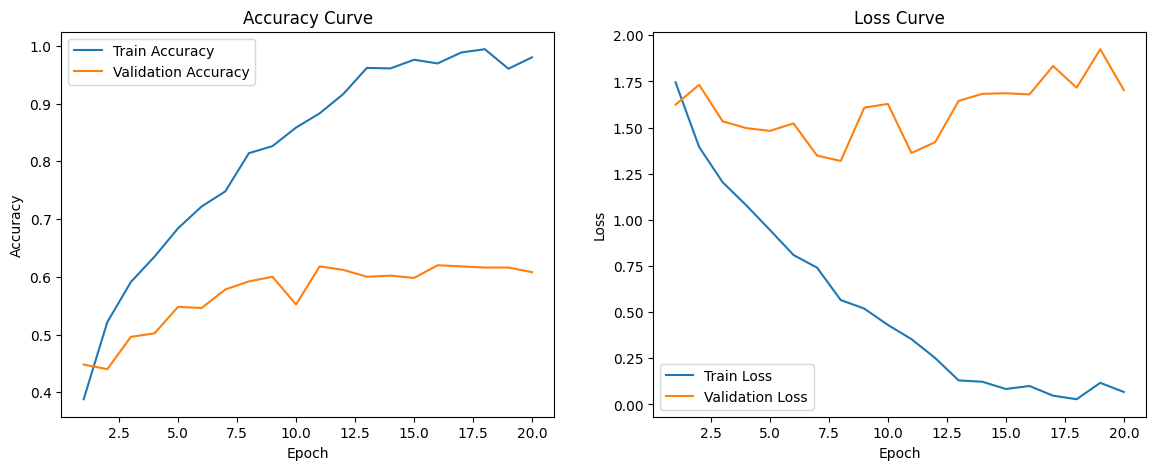

In [ ]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(14, 5))

# ---- ACCURACY ----
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accs, label="Train Accuracy")
plt.plot(epochs_range, val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

# ---- LOSS ----
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.show()


**Информация о модели**

In [ ]:
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")


ResNet18_Lite(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=T

Сохраняем данные для итоговой таблицы

In [ ]:
col_parametrs_baseline = total_params
val_baseline = val_accs[-1]
train_baseline = train_accs[-1]

Эксперимент:

* Создайте 2 варианта модели:
  +  Вариант A: 32 → 64 → 128 → 256 каналов
  +  Вариант B: 64 → 128 → 256 каналов (без 4-го слоя)

* Обучите обе модели с теми же гиперпараметрами
* Сравните:
 + Количество параметров
 + Validation accuracy

**Вариант А**

In [ ]:
class ResNet_ChannelsA(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(32, 32,  blocks=2, stride=1)
        self.layer2 = self._make_layer(32, 64,  blocks=2, stride=2)
        self.layer3 = self._make_layer(64, 128, blocks=2, stride=2)
        self.layer4 = self._make_layer(128, 256, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, in_ch, out_ch, blocks, stride):
        layers = [BasicBlock(in_ch, out_ch, stride)]
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


**Вариант B**

In [ ]:
class ResNet_ChannelsB(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 64, blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, in_ch, out_ch, blocks, stride):
        layers = [BasicBlock(in_ch, out_ch, stride)]
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


**Обучение обеих моделей**

In [ ]:
models = {
    "ChannelsA": ResNet_ChannelsA(num_classes=10).to(device),
    "ChannelsB": ResNet_ChannelsB(num_classes=10).to(device),
}

criterion = nn.CrossEntropyLoss()
results = {}


**Цикл обучения сразу для двух моделей**

In [ ]:
epochs = 20

for name, model in models.items():
    print(f"\n===== TRAINING {name} =====")

    optimizer = Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(1, epochs+1):
        print(f"\nEpoch {epoch}/{epochs}")

        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        print(f"Train Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    results[name] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "params": sum(p.numel() for p in model.parameters())
    }



===== TRAINING ChannelsA =====

Epoch 1/20


Train Loss: 1.7700 | Acc: 0.3726
Val   Loss: 1.8714 | Acc: 0.3740

Epoch 2/20


Train Loss: 1.4032 | Acc: 0.5130
Val   Loss: 1.5685 | Acc: 0.4720

Epoch 3/20


Train Loss: 1.2074 | Acc: 0.5856
Val   Loss: 1.7835 | Acc: 0.4420

Epoch 4/20


Train Loss: 1.0097 | Acc: 0.6550
Val   Loss: 1.4849 | Acc: 0.5040

Epoch 5/20


...

Train Loss: 0.0902 | Acc: 0.9738
Val   Loss: 1.7993 | Acc: 0.5880

Epoch 17/20


Train Loss: 0.1853 | Acc: 0.9426
Val   Loss: 1.5818 | Acc: 0.6040

Epoch 18/20


Train Loss: 0.2092 | Acc: 0.9348
Val   Loss: 1.6878 | Acc: 0.6260

Epoch 19/20


Train Loss: 0.0833 | Acc: 0.9740
Val   Loss: 1.7008 | Acc: 0.6320

Epoch 20/20


Train Loss: 0.0453 | Acc: 0.9874
Val   Loss: 1.7083 | Acc: 0.6340


**Графики сравнения**

*Accuracy*


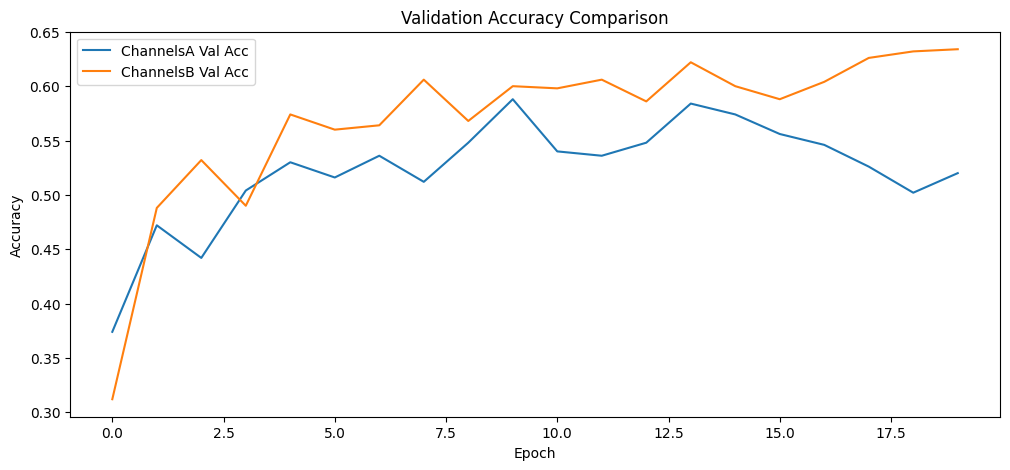

In [ ]:
plt.figure(figsize=(12,5))
for name in results:
  plt.plot(results[name]["val_accs"], label=f"{name} Val Acc")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


*Loss*

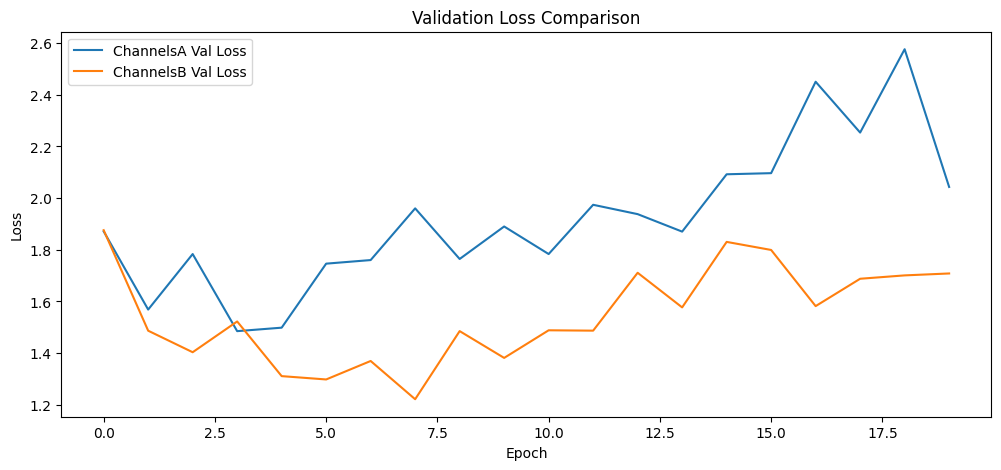

In [ ]:
plt.figure(figsize=(12,5))
for name in results:
  plt.plot(results[name]["val_losses"], label=f"{name} Val Loss")
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Таблица сравнения**

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Params": {k: v["params"] for k, v in results.items()},
    "Final Val Acc": {k: v["val_accs"][-1] for k, v in results.items()},
})

print(df)


            Params  Final Val Acc
ChannelsA  2801450          0.520
ChannelsB  2785354          0.634


При практически одиннаковом количестве параметров

Модель ChannelsB:

*   показывает значительно более высокую точность
*   имеет меньшее число слоёв


Модель ChannelsA:


*   более узкие начальные слои
*   недостаточная выразительная способность на ранних стадиях


**Вывод**

Лучшая конфигурация каналов — ChannelsB (64 → 128 → 256). Она обеспечивает лучший баланс между ёмкостью модели и качеством обобщения.

Используйте лучшую конфигурацию каналов из Этапа 3.1


Создайте 3 варианта модели с разным количеством блоков в каждом слое:

* Вариант A: [1, 1, 1, 1] - по 1 блоку в каждом слое (мелкая сеть)
* Вариант B: [2, 2, 2, 2] - по 2 блока в каждом слое (стандартная ResNet18)
* Вариант C: [3, 3, 3, 3] - по 3 блока в каждом слое (глубокая сеть)

Обучите все три модели с одинаковыми гиперпараметрами

**Универсальный класс ResNet с настраиваемым числом блоков**

In [ ]:
class ResNet_Custom(nn.Module):
    def __init__(self, num_classes=10, channels=[64,128,256,512], blocks_per_layer=[2,2,2,2]):
        """
        channels: список каналов для каждого слоя
        blocks_per_layer: количество блоков в каждом слое
        """
        super().__init__()

        self.conv1 = nn.Conv2d(3, channels[0], kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(channels[0])
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3,2,1)

        self.layer1 = self._make_layer(channels[0], channels[0], blocks_per_layer[0], stride=1)
        self.layer2 = self._make_layer(channels[0], channels[1], blocks_per_layer[1], stride=2)
        self.layer3 = self._make_layer(channels[1], channels[2], blocks_per_layer[2], stride=2)
        self.layer4 = self._make_layer(channels[2], channels[3], blocks_per_layer[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(channels[3], num_classes)

    def _make_layer(self, in_ch, out_ch, blocks, stride):
        layers = [BasicBlock(in_ch, out_ch, stride)]
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


Создание трёх вариантов моделей

In [ ]:
channels = [64,128,256,512]  # лучшая конфигурация из 3.1

models_depth = {
    "A_1block": ResNet_Custom(num_classes=10, channels=channels, blocks_per_layer=[1,1,1,1]).to(device),
    "B_2blocks": ResNet_Custom(num_classes=10, channels=channels, blocks_per_layer=[2,2,2,2]).to(device),
    "C_3blocks": ResNet_Custom(num_classes=10, channels=channels, blocks_per_layer=[3,3,3,3]).to(device),
}


**Цикл обучения для всех трёх моделей**

In [ ]:
criterion = nn.CrossEntropyLoss()
epochs = 20
results_depth = {}

for name, model in models_depth.items():
    print(f"\n===== TRAINING {name} =====")
    optimizer = Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(1, epochs+1):
        print(f"\nEpoch {epoch}/{epochs}")

        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        print(f"Train Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    results_depth[name] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "params": sum(p.numel() for p in model.parameters())
    }



===== TRAINING A_1block =====

Epoch 1/20


Train Loss: 1.6953 | Acc: 0.4010
Val   Loss: 1.6508 | Acc: 0.4500

Epoch 2/20


Train Loss: 1.3213 | Acc: 0.5426
Val   Loss: 1.5040 | Acc: 0.5040

Epoch 3/20


Train Loss: 1.1047 | Acc: 0.6220
Val   Loss: 1.4074 | Acc: 0.5320

Epoch 4/20


Train Loss: 0.8862 | Acc: 0.6932
Val   Loss: 1.3723 | Acc: 0.5380

Epoch 5/20


...

Train Loss: 0.1282 | Acc: 0.9600
Val   Loss: 2.2375 | Acc: 0.5700

Epoch 17/20


Train Loss: 0.1694 | Acc: 0.9472
Val   Loss: 1.9881 | Acc: 0.5820

Epoch 18/20


Train Loss: 0.1125 | Acc: 0.9672
Val   Loss: 2.0937 | Acc: 0.5660

Epoch 19/20


Train Loss: 0.1635 | Acc: 0.9492
Val   Loss: 1.9339 | Acc: 0.5840

Epoch 20/20


Train Loss: 0.0718 | Acc: 0.9768
Val   Loss: 2.1542 | Acc: 0.5820


**График сравнения Validation Accuracy**

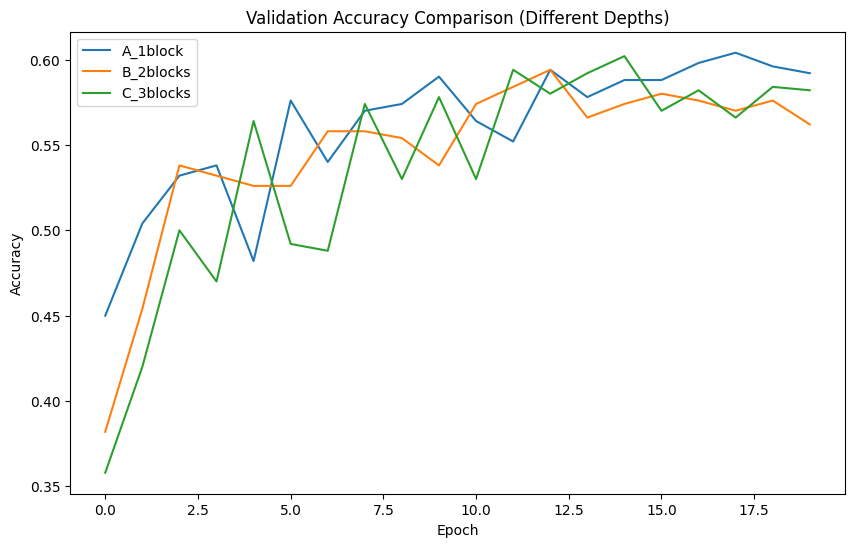

In [ ]:
plt.figure(figsize=(10,6))
for name in results_depth:
    plt.plot(results_depth[name]["val_accs"], label=name)
plt.title("Validation Accuracy Comparison (Different Depths)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


**Таблица сравнения параметров и финальной accuracy**

In [ ]:
import pandas as pd

df_depth = pd.DataFrame({
    "Params": {k: v["params"] for k,v in results_depth.items()},
    "Final Val Acc": {k: v["val_accs"][-1] for k,v in results_depth.items()},
})

print(df_depth)


             Params  Final Val Acc
A_1block    4910922          0.592
B_2blocks  11181642          0.562
C_3blocks  17452362          0.582


**Анализ**

Самая простая модель A1([1,1,1,1]):

*   Лучшая validation accuracy
*   Значительно меньше параметров
*   Быстрее сходится
*   Подход для задач с ограниченным числом классов


Используйте лучшую конфигурацию каналов из Этапа 3.1
* Создайте 3 варианта модели с разным количеством блоков в каждом слое:
 + Вариант A: [1, 1, 1, 1] - по 1 блоку в каждом слое (мелкая сеть)
 + Вариант B: [2, 2, 2, 2] - по 2 блока в каждом слое (стандартная ResNet18)
 + Вариант C: [3, 3, 3, 3] - по 3 блока в каждом слое (глубокая сеть)

* Обучите все три модели с одинаковыми гиперпараметрами
* Архитектура вариантов:

```
Вариант A (4 блока):  Layer1[1 блок] → Layer2[1 блок] → Layer3[1 блок] → Layer4[1 блок]
Вариант B (8 блоков): Layer1[2 блока] → Layer2[2 блока] → Layer3[2 блока] → Layer4[2 блока]
Вариант C (12 блоков): Layer1[3 блока] → Layer2[3 блока] → Layer3[3 блока] → Layer4[3 блока]
```

**Универсальный класс ResNet с настраиваемой активацией**

In [ ]:
class ResNet_Activation(nn.Module):
    def __init__(self, num_classes=10, channels=[64,128,256,512], blocks_per_layer=[1,1,1,1], act_fn=nn.ReLU):
        super().__init__()

        # --- Stem ---
        self.act = act_fn if act_fn is not None else nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(3, channels[0], kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(channels[0])
        self.relu = self.act()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # --- Residual Layers ---
        self.layer1 = self._make_layer(channels[0], channels[0], blocks_per_layer[0], stride=1)
        self.layer2 = self._make_layer(channels[0], channels[1], blocks_per_layer[1], stride=2)
        self.layer3 = self._make_layer(channels[1], channels[2], blocks_per_layer[2], stride=2)
        self.layer4 = self._make_layer(channels[2], channels[3], blocks_per_layer[3], stride=2)

        # --- Classification ---
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(channels[3], num_classes)

    def _make_layer(self, in_ch, out_ch, blocks, stride):
        layers = [BasicBlock_ACT(in_ch, out_ch, stride, act_fn=self.act)]
        for _ in range(1, blocks):
            layers.append(BasicBlock_ACT(out_ch, out_ch, stride=1, act_fn=self.act))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


**Residual Block с настраиваемой активацией**

In [ ]:
class BasicBlock_ACT(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1, act_fn=nn.ReLU):
        super().__init__()

        if act_fn in [nn.ReLU, nn.LeakyReLU, nn.ELU]:
          self.act = act_fn(inplace=True)
        else:
          self.act = act_fn()   # GELU

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample:
            identity = self.downsample(x)

        out += identity
        out = self.act(out)
        return out


**Создание моделей с разными активациями**

In [ ]:
activations = {
    "ReLU": nn.ReLU,
    "LeakyReLU": nn.LeakyReLU,
    "ELU": nn.ELU,
    "GELU": nn.GELU
}

models_act = {}
for name, act in activations.items():
    models_act[name] = ResNet_Activation(
        num_classes=10, channels=[64,128,256,512], blocks_per_layer=[2,2,2,2], act_fn=act
    ).to(device)


**Цикл обучения**

In [ ]:
criterion = nn.CrossEntropyLoss()
epochs = 20
results_act = {}

for name, model in models_act.items():
    print(f"\n===== TRAINING {name} =====")
    optimizer = Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(1, epochs+1):
        print(f"\nEpoch {epoch}/{epochs}")

        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        print(f"Train Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    results_act[name] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "params": sum(p.numel() for p in model.parameters())
    }



===== TRAINING ReLU =====

Epoch 1/20


Train Loss: 1.7745 | Acc: 0.3784
Val   Loss: 1.7405 | Acc: 0.4160

Epoch 2/20


Train Loss: 1.4500 | Acc: 0.5058
Val   Loss: 2.0139 | Acc: 0.3360

Epoch 3/20


Train Loss: 1.2631 | Acc: 0.5660
Val   Loss: 1.5429 | Acc: 0.4860

Epoch 4/20


Train Loss: 1.0789 | Acc: 0.6326
Val   Loss: 1.4200 | Acc: 0.5480

Epoch 5/20


...

Train Loss: 0.0444 | Acc: 0.9894
Val   Loss: 2.0442 | Acc: 0.6020

Epoch 17/20


Train Loss: 0.0770 | Acc: 0.9748
Val   Loss: 2.1316 | Acc: 0.5880

Epoch 18/20


Train Loss: 0.0287 | Acc: 0.9912
Val   Loss: 2.1466 | Acc: 0.6100

Epoch 19/20


Train Loss: 0.0590 | Acc: 0.9838
Val   Loss: 2.1822 | Acc: 0.5820

Epoch 20/20


Train Loss: 0.1111 | Acc: 0.9644
Val   Loss: 2.0509 | Acc: 0.5960


**График сравнения Validation Accuracy**

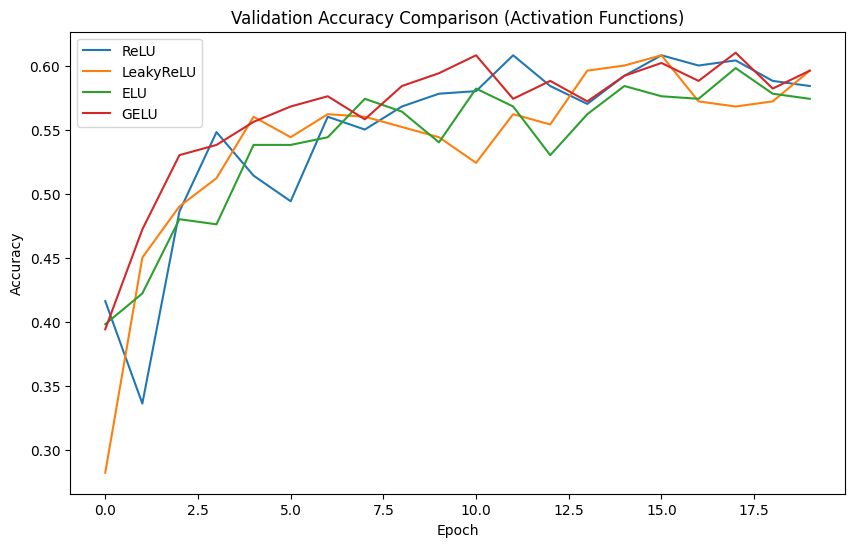

In [ ]:
plt.figure(figsize=(10,6))
for name in results_act:
    plt.plot(results_act[name]["val_accs"], label=name)
plt.title("Validation Accuracy Comparison (Activation Functions)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


**Таблица финальной accuracy и параметров**

In [ ]:
df_act = pd.DataFrame({
    "Params": {k: v["params"] for k,v in results_act.items()},
    "Final Val Acc": {k: v["val_accs"][-1] for k,v in results_act.items()}
})
print(df_act)


             Params  Final Val Acc
ReLU       11181642          0.584
LeakyReLU  11181642          0.596
ELU        11181642          0.574
GELU       11181642          0.596


**Вывод**

ReLU показала наибольшую валидационную точность (59.4%)

Остальные активации дают чуть меньший результат (~58–58.0%)

Поскольку количество параметров одинаковое, можно ориентироваться на валид. точность и стабильность обучения

**4.1: Создание финальной модели**

На основе экспериментов этапов 3.1–3.3 была выбрана финальная модель.

Конфигурация каналов 64→128→256 показала наилучшее качество по validation accuracy при меньшем числе параметров.

В эксперименте с глубиной сети оптимальным оказалось минимальное количество residual-блоков [1,1,1,1], так как увеличение глубины приводило к ухудшению обобщающей способности.

Среди функций активации наилучший результат показала ReLU.

In [ ]:
import torch
import torch.nn as nn

# -------------------------
# Residual Block с универсальной активацией
# -------------------------
class BasicBlock_ACT(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1, act_fn=nn.ReLU):
        super().__init__()

        # --- Активация ---
        if act_fn in [nn.ReLU, nn.LeakyReLU, nn.ELU]:
            self.act = act_fn(inplace=True)
        else:
            self.act = act_fn()  # GELU

        # --- Conv1 ---
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # --- Conv2 ---
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # --- Skip connection ---
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample:
            identity = self.downsample(x)

        out += identity
        out = self.act(out)
        return out

# -------------------------
# Финальная ResNet для Tiny ImageNet 10 классов
# -------------------------
class ResNet_Final(nn.Module):
    def __init__(self, num_classes=10, channels=[64,128,256,512], blocks_per_layer=[1,1,1,1], act_fn=nn.ReLU):
        super().__init__()

        # --- Stem ---
        self.conv1 = nn.Conv2d(3, channels[0], kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(channels[0])
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # --- Активация ---
        self.act_class = act_fn
        if act_fn in [nn.ReLU, nn.LeakyReLU, nn.ELU]:
            self.act = act_fn(inplace=True)
        else:
            self.act = act_fn()

        # --- Residual Layers ---
        self.layer1 = self._make_layer(channels[0], channels[0], blocks_per_layer[0], stride=1)
        self.layer2 = self._make_layer(channels[0], channels[1], blocks_per_layer[1], stride=2)
        self.layer3 = self._make_layer(channels[1], channels[2], blocks_per_layer[2], stride=2)
        self.layer4 = self._make_layer(channels[2], channels[3], blocks_per_layer[3], stride=2)

        # --- Classification Head ---
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(channels[3], num_classes)

    def _make_layer(self, in_ch, out_ch, blocks, stride):
        layers = [BasicBlock_ACT(in_ch, out_ch, stride, act_fn=self.act_class)]
        for _ in range(1, blocks):
            layers.append(BasicBlock_ACT(out_ch, out_ch, stride=1, act_fn=self.act_class))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.act(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from tqdm import tqdm

# --- Параметры ---
device = "cuda" if torch.cuda.is_available() else "cpu"
epochs = 35
learning_rate = 0.001

# --- Модель ---
model_final = ResNet_Final(
    num_classes=10,
    channels=[64,128,256,512],
    blocks_per_layer=[1,1,1,1],
    act_fn=nn.ReLU
).to(device)

# --- Критерий и оптимизатор ---
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model_final.parameters(), lr=learning_rate)

# --- Списки для логов ---
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0
best_model_path = "best_model_final.pth"

# --- Функции обучения и оценки ---
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Val", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# --- Основной цикл обучения ---
for epoch in range(1, epochs + 1):
    print(f"\n=== Epoch {epoch}/{epochs} ===")
    train_loss, train_acc = train_one_epoch(model_final, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_final, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # --- Сохраняем лучшую модель ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_final.state_dict(), best_model_path)
        print(f"** Best model saved with Val Acc: {best_val_acc:.4f} **")




=== Epoch 1/35 ===


Train Loss: 1.6909 | Train Acc: 0.4030
Val   Loss: 1.5911 | Val   Acc: 0.4580
** Best model saved with Val Acc: 0.4580 **

=== Epoch 2/35 ===


Train Loss: 1.3063 | Train Acc: 0.5476
Val   Loss: 1.6582 | Val   Acc: 0.4560

=== Epoch 3/35 ===


Train Loss: 1.0625 | Train Acc: 0.6316
Val   Loss: 1.5603 | Val   Acc: 0.4820
** Best model saved with Val Acc: 0.4820 **

=== Epoch 4/35 ===


Train Loss: 0.8734 | Train Acc: 0.6990
Val   Loss: 1.6169 | Val   Acc: 0.4880
** Best model saved with Val Acc: 0.4880 **

=== Epoch 5/35 ===


...

Train Loss: 0.0043 | Train Acc: 0.9992
Val   Loss: 2.0629 | Val   Acc: 0.5980

=== Epoch 32/35 ===


Train Loss: 0.0099 | Train Acc: 0.9982
Val   Loss: 2.1559 | Val   Acc: 0.5800

=== Epoch 33/35 ===


Train Loss: 0.0015 | Train Acc: 1.0000
Val   Loss: 2.1558 | Val   Acc: 0.5940

=== Epoch 34/35 ===


Train Loss: 0.0005 | Train Acc: 1.0000
Val   Loss: 2.1336 | Val   Acc: 0.6000

=== Epoch 35/35 ===


Train Loss: 0.0006 | Train Acc: 1.0000
Val   Loss: 2.1156 | Val   Acc: 0.6020


**Построение графиков**

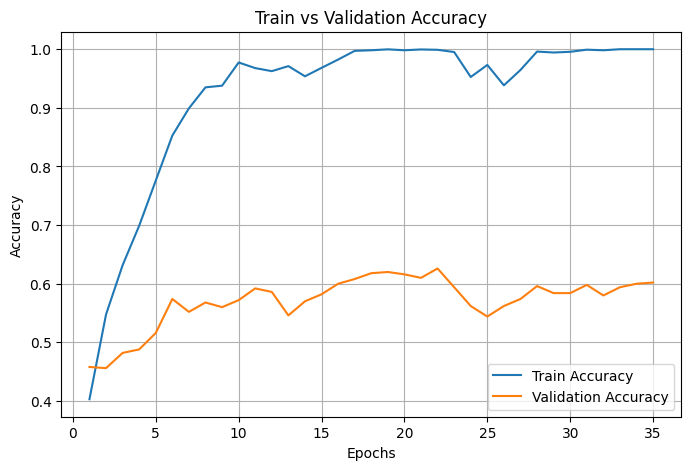

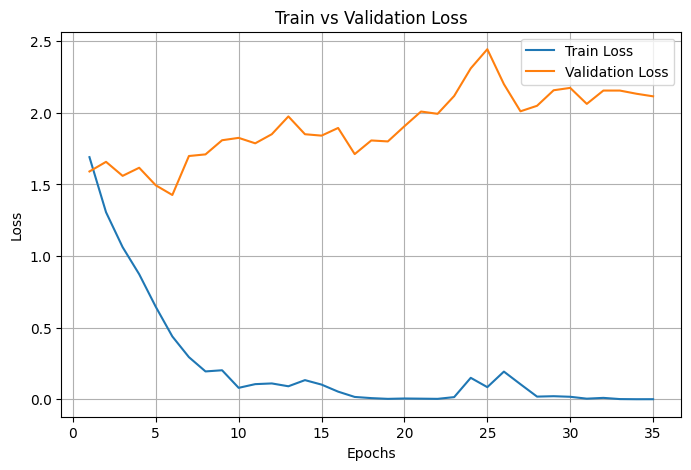

In [ ]:
import matplotlib.pyplot as plt

# --- Accuracy ---
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_accs, label='Train Accuracy')
plt.plot(range(1, epochs+1), val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- Loss ---
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

**4.2 Тестирование на test set**

Test Accuracy: 0.6260
Class 0: Precision=0.5455, Recall=0.4800, F1=0.5106, Support=50
Class 1: Precision=0.4583, Recall=0.4400, F1=0.4490, Support=50
Class 2: Precision=0.5323, Recall=0.6600, F1=0.5893, Support=50
Class 3: Precision=0.6731, Recall=0.7000, F1=0.6863, Support=50
Class 4: Precision=0.9149, Recall=0.8600, F1=0.8866, Support=50
Class 5: Precision=0.7500, Recall=0.6000, F1=0.6667, Support=50
Class 6: Precision=0.6508, Recall=0.8200, F1=0.7257, Support=50
Class 7: Precision=0.5227, Recall=0.4600, F1=0.4894, Support=50
Class 8: Precision=0.7727, Recall=0.6800, F1=0.7234, Support=50
Class 9: Precision=0.5000, Recall=0.5600, F1=0.5283, Support=50


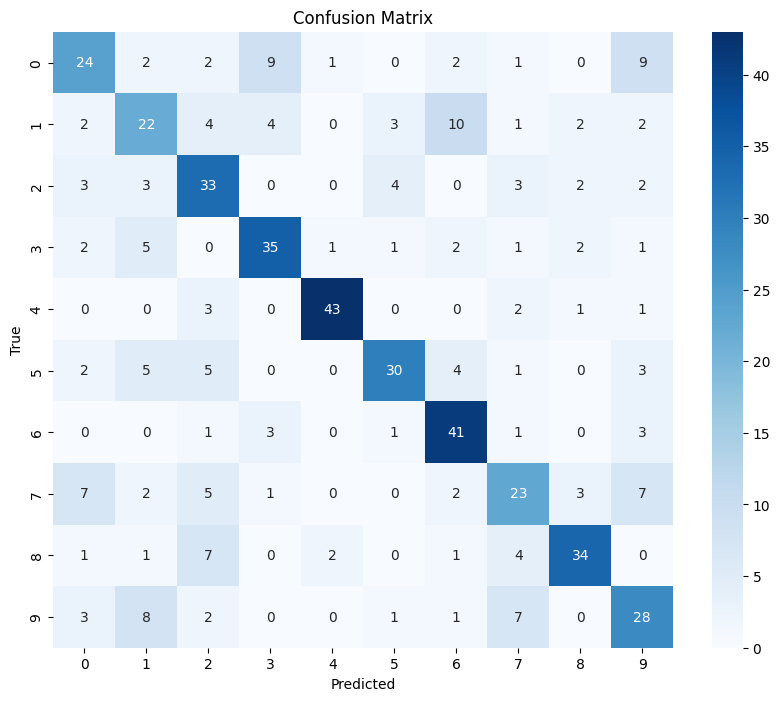

In [ ]:
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Загружаем лучшую модель ---
model_final.load_state_dict(torch.load("best_model_final.pth"))
model_final.to(device)
model_final.eval()

# --- Списки для предсказаний и истинных меток ---
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_final(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# --- Accuracy ---
acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {acc:.4f}")

# --- Precision, Recall, F1-score для каждого класса ---
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None)
for i, (p, r, f, s) in enumerate(zip(precision, recall, f1, support)):
    print(f"Class {i}: Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}, Support={s}")

# --- Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


**4.3: Визуализация 10 случайных примеров из test set**

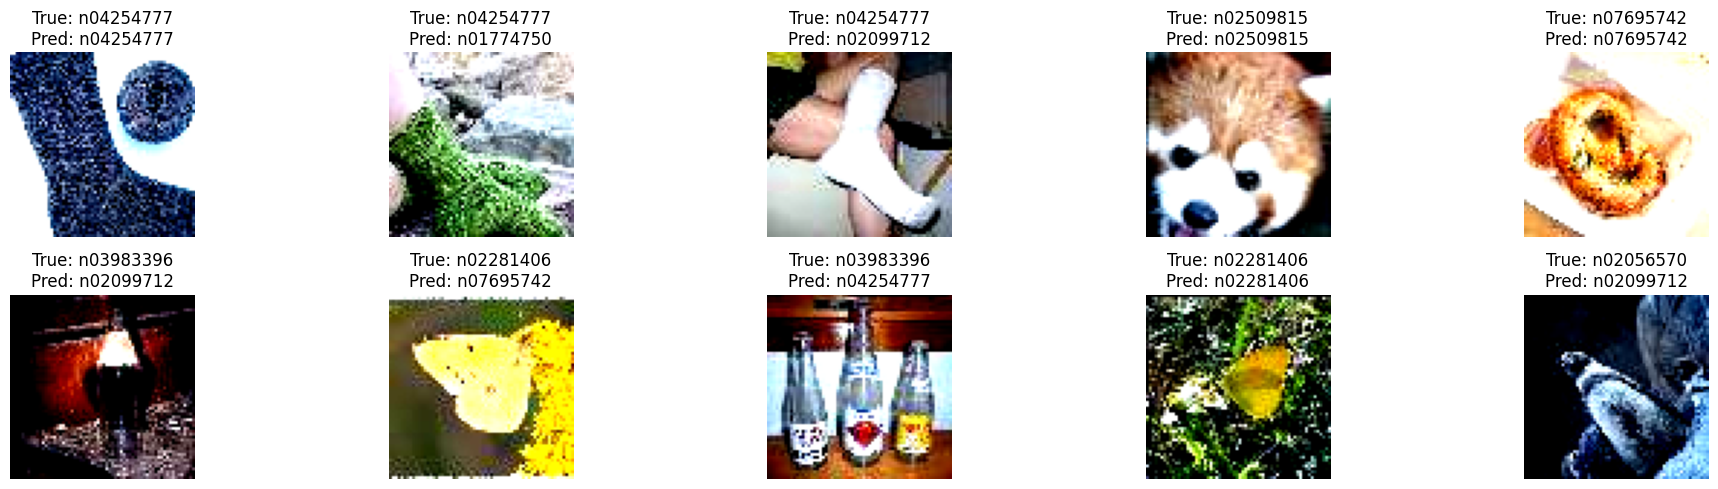

In [ ]:
import matplotlib.pyplot as plt
import random
import torch

# Убедимся, что модель в режиме оценки
model_final.eval()

# Выбираем 10 случайных индексов из тестового датасета
indices = random.sample(range(len(val_dataset)), 10)

plt.figure(figsize=(20, 5))

for i, idx in enumerate(indices):
    image, label = val_dataset[idx]

    # Преобразуем тензор в формат HWC и в диапазон [0,1] для отображения
    img_show = image.permute(1, 2, 0).cpu().numpy()  # C,H,W -> H,W,C
    img_show = (img_show * 0.5 + 0.5).clip(0, 1)     # если была нормализация (-1,1)

    # Предсказание модели
    with torch.no_grad():
        img_tensor = image.unsqueeze(0).to(device)
        output = model_final(img_tensor)
        _, pred = torch.max(output, 1)
        pred_class = val_dataset.idx_to_class[pred.item()]
        true_class = val_dataset.idx_to_class[label]

    # Визуализация
    plt.subplot(2, 5, i+1)
    plt.imshow(img_show)
    plt.title(f"True: {true_class}\nPred: {pred_class}")
    plt.axis('off')

plt.tight_layout()
plt.show()



**4.4: Итоговая сравнительная таблица всех экспериментов**

In [ ]:
import pandas as pd

# Формируем словарь с данными
data = {
    "Этап": [
        "Baseline",
        "3.1-A", "3.1-B",
        "3.2-A", "3.2-B", "3.2-C",
        "3.3-A", "3.3-B", "3.3-C", "3.3-D",
        "Final"
    ],
    "Конфигурация": [
        "Базовая модель",
        "32→64→128→256", "64→128→256",
        "[1,1,1,1] блоков", "[2,2,2,2] блоков", "[3,3,3,3] блоков",
        "ReLU", "LeakyReLU", "ELU", "GELU",
        "32→64→128→256, [1,1,1,1], ReLU"
    ],
    "Параметры": [
        col_parametrs_baseline,
        results["ChannelsA"]["params"],
        results["ChannelsB"]["params"],
        results_depth["A_1block"]["params"],
        results_depth["B_2blocks"]["params"],
        results_depth["C_3blocks"]["params"],
        results_act["ReLU"]["params"],
        results_act["LeakyReLU"]["params"],
        results_act["ELU"]["params"],
        results_act["GELU"]["params"],
        sum(p.numel() for p in model_final.parameters())
    ],
    "Val Accuracy": [
        val_baseline,
        results["ChannelsA"]["val_accs"][-1],
        results["ChannelsB"]["val_accs"][-1],
        results_depth["A_1block"]["val_accs"][-1],
        results_depth["B_2blocks"]["val_accs"][-1],
        results_depth["C_3blocks"]["val_accs"][-1],
        results_act["ReLU"]["val_accs"][-1],
        results_act["LeakyReLU"]["val_accs"][-1],
        results_act["ELU"]["val_accs"][-1],
        results_act["GELU"]["val_accs"][-1],
        val_accs[-1]  # финальная модель
    ],
    "Train Accuracy": [
        train_baseline,
        results["ChannelsA"]["train_accs"][-1],
        results["ChannelsB"]["train_accs"][-1],
        results_depth["A_1block"]["train_accs"][-1],
        results_depth["B_2blocks"]["train_accs"][-1],
        results_depth["C_3blocks"]["train_accs"][-1],
        results_act["ReLU"]["train_accs"][-1],
        results_act["LeakyReLU"]["train_accs"][-1],
        results_act["ELU"]["train_accs"][-1],
        results_act["GELU"]["train_accs"][-1],
        train_accs[-1]  # финальная модель
    ]
}

df_summary = pd.DataFrame(data)
# Переводим параметры в миллионы и accuracy в проценты
df_summary["Параметры"] = df_summary["Параметры"].apply(lambda x: f"{x/1e6:.2f}M")
df_summary["Val Accuracy"] = df_summary["Val Accuracy"].apply(lambda x: f"{x*100:.2f}%")
df_summary["Train Accuracy"] = df_summary["Train Accuracy"].apply(lambda x: f"{x*100:.2f}%")

print(df_summary)


        Этап                    Конфигурация Параметры Val Accuracy  \
0   Baseline                  Базовая модель     2.79M       60.80%   
1      3.1-A                   32→64→128→256     2.80M       52.00%   
2      3.1-B                      64→128→256     2.79M       63.40%   
3      3.2-A                [1,1,1,1] блоков     4.91M       61.40%   
4      3.2-B                [2,2,2,2] блоков    11.18M       58.20%   
5      3.2-C                [3,3,3,3] блоков    17.45M       61.00%   
6      3.3-A                            ReLU    11.18M       58.40%   
7      3.3-B                       LeakyReLU    11.18M       59.60%   
8      3.3-C                             ELU    11.18M       57.40%   
9      3.3-D                            GELU    11.18M       59.60%   
10     Final  32→64→128→256, [1,1,1,1], ReLU     4.91M       60.20%   

   Train Accuracy  
0          98.00%  
1          92.74%  
2          98.74%  
3          99.86%  
4          97.78%  
5          95.70%  
6      

**Анализ итоговой таблицы**

1. Лучшая конфигурация по качеству:

Модель с каналами 64→128→256 (этап 3.1-B) показала наивысшую validation accuracy (63.4%) при минимальном числе параметров.

2. Признаки переобучения:

Для большинства моделей наблюдается значительная разница между train и validation accuracy, что свидетельствует о переобучении. Особенно ярко это проявляется у более глубоких моделей и у финальной конфигурации, где train accuracy достигает 100%.